In [4]:
import os
import sys
import copy
import pandas as pd
import numpy as np

# get the absolute path of the current file
current_dir = os.path.dirname(os.path.abspath("__file__"))
# get the project root (one level up from notebooks/)
project_root = os.path.abspath(os.path.join(current_dir, ".."))
# add project root to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)

In [50]:
%reload_ext autoreload
%autoreload 2

from utils.stock_utils import download_stock_data
from utils.kpi import CAGR, volatility, Sharpe, max_dd, Sortino, calamar, jensens_alpha
from utils.technical_indicators import ATR

In [6]:
nifty_top_20 = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "AXISBANK.NS", 
    "TCS.NS", "LT.NS", "BHARTIARTL.NS", "SBIN.NS", "ITC.NS", 
    "HINDUNILVR.NS", "BAJFINANCE.NS", "KOTAKBANK.NS", "MARUTI.NS", "M&M.NS", 
    "TATASTEEL.NS", "SUNPHARMA.NS", "HCLTECH.NS", "ADANIENT.NS", "NTPC.NS"
]

In [8]:
ohlcv_intraday = download_stock_data(nifty_top_20, 30, "5m")

YF.download() has changed argument auto_adjust default to True
Successfully downloaded 20/20 stocks.


In [10]:
# calculating ATR and rolling max price for each stock and consolidating this info by stock in a separate dataframe
ohlcv_dict = copy.deepcopy(ohlcv_intraday)
tickers_signal = {}
tickers_ret = {}
for ticker in nifty_top_20:
    print("calculating ATR and rolling max price for ",ticker)
    ohlcv_dict[ticker]["ATR"] = ATR(ohlcv_dict[ticker],20)
    ohlcv_dict[ticker]["roll_max_cp"] = ohlcv_dict[ticker]["High"].rolling(20).max()
    ohlcv_dict[ticker]["roll_min_cp"] = ohlcv_dict[ticker]["Low"].rolling(20).min()
    ohlcv_dict[ticker]["roll_max_vol"] = ohlcv_dict[ticker]["Volume"].rolling(20).max()
    ohlcv_dict[ticker].dropna(inplace=True)
    tickers_signal[ticker] = ""
    tickers_ret[ticker] = [0]

calculating ATR and rolling max price for  RELIANCE.NS
calculating ATR and rolling max price for  HDFCBANK.NS
calculating ATR and rolling max price for  ICICIBANK.NS
calculating ATR and rolling max price for  INFY.NS
calculating ATR and rolling max price for  AXISBANK.NS
calculating ATR and rolling max price for  TCS.NS
calculating ATR and rolling max price for  LT.NS
calculating ATR and rolling max price for  BHARTIARTL.NS
calculating ATR and rolling max price for  SBIN.NS
calculating ATR and rolling max price for  ITC.NS
calculating ATR and rolling max price for  HINDUNILVR.NS
calculating ATR and rolling max price for  BAJFINANCE.NS
calculating ATR and rolling max price for  KOTAKBANK.NS
calculating ATR and rolling max price for  MARUTI.NS
calculating ATR and rolling max price for  M&M.NS
calculating ATR and rolling max price for  TATASTEEL.NS
calculating ATR and rolling max price for  SUNPHARMA.NS
calculating ATR and rolling max price for  HCLTECH.NS
calculating ATR and rolling max 

In [11]:
# identifying signals and calculating daily return
for ticker in nifty_top_20:
    print("calculating returns for ", ticker)
    
    # FIX 1: Reset the signal and the list for EVERY ticker/run
    tickers_signal[ticker] = ""
    tickers_ret[ticker] = [0] # FIX 2: Start with [0] to account for the first row (index 0)
    
    df = ohlcv_dict[ticker] # Shorthand for readability

    for i in range(1, len(df)):
        if tickers_signal[ticker] == "":
            tickers_ret[ticker].append(0)
            # Breakout logic
            if df["High"].iloc[i] >= df["roll_max_cp"].iloc[i] and \
               df["Volume"].iloc[i] > 1.5 * df["roll_max_vol"].iloc[i-1]:
                tickers_signal[ticker] = "Buy"
            elif df["Low"].iloc[i] <= df["roll_min_cp"].iloc[i] and \
                 df["Volume"].iloc[i] > 1.5 * df["roll_max_vol"].iloc[i-1]:
                tickers_signal[ticker] = "Sell"
        
        elif tickers_signal[ticker] == "Buy":
            # Stop loss (ATR)
            if df["Low"].iloc[i] < df["Close"].iloc[i-1] - df["ATR"].iloc[i-1]:
                tickers_signal[ticker] = ""
                # Calculate return at stop loss price
                ret = ((df["Close"].iloc[i-1] - df["ATR"].iloc[i-1]) / df["Close"].iloc[i-1]) - 1
                tickers_ret[ticker].append(ret)
            # Reverse signal
            elif df["Low"].iloc[i] <= df["roll_min_cp"].iloc[i] and \
                 df["Volume"].iloc[i] > 1.5 * df["roll_max_vol"].iloc[i-1]:
                tickers_signal[ticker] = "Sell"
                tickers_ret[ticker].append((df["Close"].iloc[i] / df["Close"].iloc[i-1]) - 1)
            else:
                tickers_ret[ticker].append((df["Close"].iloc[i] / df["Close"].iloc[i-1]) - 1)
                
        elif tickers_signal[ticker] == "Sell":
            # Stop loss (ATR)
            if df["High"].iloc[i] > df["Close"].iloc[i-1] + df["ATR"].iloc[i-1]:
                tickers_signal[ticker] = ""
                # Calculate return for short position at stop loss
                ret = (df["Close"].iloc[i-1] / (df["Close"].iloc[i-1] + df["ATR"].iloc[i-1])) - 1
                tickers_ret[ticker].append(ret)
            # Reverse signal
            elif df["High"].iloc[i] >= df["roll_max_cp"].iloc[i] and \
                 df["Volume"].iloc[i] > 1.5 * df["roll_max_vol"].iloc[i-1]:
                tickers_signal[ticker] = "Buy"
                tickers_ret[ticker].append((df["Close"].iloc[i-1] / df["Close"].iloc[i]) - 1)
            else:
                tickers_ret[ticker].append((df["Close"].iloc[i-1] / df["Close"].iloc[i]) - 1)
                
    # Now lengths are guaranteed to match
    ohlcv_dict[ticker]["ret"] = np.array(tickers_ret[ticker])

calculating returns for  RELIANCE.NS
calculating returns for  HDFCBANK.NS
calculating returns for  ICICIBANK.NS
calculating returns for  INFY.NS
calculating returns for  AXISBANK.NS
calculating returns for  TCS.NS
calculating returns for  LT.NS
calculating returns for  BHARTIARTL.NS
calculating returns for  SBIN.NS
calculating returns for  ITC.NS
calculating returns for  HINDUNILVR.NS
calculating returns for  BAJFINANCE.NS
calculating returns for  KOTAKBANK.NS
calculating returns for  MARUTI.NS
calculating returns for  M&M.NS
calculating returns for  TATASTEEL.NS
calculating returns for  SUNPHARMA.NS
calculating returns for  HCLTECH.NS
calculating returns for  ADANIENT.NS
calculating returns for  NTPC.NS


In [20]:
# Assuming Indian Market 5m candles
# 75 candles per day (9:15 to 3:30) * 30 days = 2250
TF = 18900 

stats = {}

for ticker in nifty_top_20:
    df = ohlcv_dict[ticker]
    
    # We pass the 'ret' column we just calculated in your signal loop
    stats[ticker] = {
        "CAGR": CAGR(df, timeframe=TF, column='ret', is_price=False),
        "Sharpe": Sharpe(df, timeframe=TF, column='ret', is_price=False),
        "Max_DD": max_dd(df, column='ret', is_price=False),
        "Vol": volatility(df, timeframe=TF, column='ret', is_price=False)
    }

# Convert to DataFrame to see it clearly
stats_df = pd.DataFrame(stats).T
print(stats_df)

                   CAGR     Sharpe    Max_DD       Vol
RELIANCE.NS   -0.144557  -4.141171  0.023260  0.042152
HDFCBANK.NS    0.185100   2.892068  0.006137  0.053629
ICICIBANK.NS   0.548568   3.279327  0.013037  0.158133
INFY.NS        0.047653   0.196917  0.020454  0.089648
AXISBANK.NS   -0.097075  -2.055956  0.017621  0.061808
TCS.NS         0.437352   4.562832  0.006512  0.089276
LT.NS          1.211948  11.772606  0.007727  0.100398
BHARTIARTL.NS  0.257072   3.904880  0.012085  0.058151
SBIN.NS        0.419114   5.126521  0.008904  0.075902
ITC.NS        -0.075038  -2.301538  0.014876  0.045638
HINDUNILVR.NS -0.201758  -7.058462  0.021101  0.032834
BAJFINANCE.NS -0.132317  -3.496700  0.021790  0.046420
KOTAKBANK.NS  -0.094768  -1.805939  0.019408  0.069087
MARUTI.NS      0.042225   0.234714  0.008810  0.052083
M&M.NS        -0.028268  -0.963616  0.015202  0.060468
TATASTEEL.NS   1.696444   8.144278  0.010918  0.204615
SUNPHARMA.NS   0.348811   6.079148  0.007948  0.052443
HCLTECH.NS

In [14]:
# 1. Extract all 'ret' columns into one DataFrame
all_returns = pd.DataFrame()

for ticker in nifty_top_20:
    # Use the 'ret' column we calculated in the signal loop
    all_returns[ticker] = ohlcv_dict[ticker]["ret"]

# 2. Calculate the Portfolio Return
# We take the mean across all tickers for each 5-minute candle
all_returns['portfolio_ret'] = all_returns.mean(axis=1)

# 3. Create a clean DataFrame for the KPI functions
portfolio_df = all_returns[['portfolio_ret']].copy()

In [51]:
# Define your annualization factor (5-min candles in a year)
TF = 18900 

portfolio_stats = {
    "Portfolio CAGR": CAGR(portfolio_df, timeframe=TF, column='portfolio_ret', is_price=False),
    "Portfolio Sharpe": Sharpe(portfolio_df, timeframe=TF, column='portfolio_ret', is_price=False),
    "Portfolio Max DD": max_dd(portfolio_df, column='portfolio_ret', is_price=False),
    "Portfolio Vol": volatility(portfolio_df, timeframe=TF, column='portfolio_ret', is_price=False)
}

# Display results
for kpi, value in portfolio_stats.items():
    if "Sharpe" in kpi:
        print(f"{kpi}: {value:.2f}")
    else:
        print(f"{kpi}: {value:.2%}")

Portfolio CAGR: 10.60%
Portfolio Sharpe: 1.69
Portfolio Max DD: 0.38%
Portfolio Vol: 2.13%


In [52]:
# Baseline - BUY & HOLD for Nifty Midcap 100

import yfinance as yf
# 1. Download Data
ticker = "^NSEI"
data = yf.download(ticker, period="30d", interval="5m")

# 2. Clean Data (yfinance multi-index handling if necessary)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 3. Calculate KPIs
# Since we are using 5min data, timeframe = 18900
# Since we downloaded ohlcv, is_price = True
TF=18900
cagr_val = CAGR(data, timeframe=TF, column='Close', is_price=True)
vol_val = volatility(data, timeframe=TF, column='Close', is_price=True)
sharpe_val = Sharpe(data, timeframe=TF, column='Close', is_price=True)
mdd_val = max_dd(data, column='Close', is_price=True)

# 4. Display Results
print(f"--- Statistics for {ticker} (Last 1 Month) ---")
print(f"CAGR:           {cagr_val:.2%}")
print(f"volatility:     {vol_val:.2%}")
print(f"Sharpe Ratio:   {sharpe_val:.2f}")
print(f"Max Drawdown:   {mdd_val:.2%}")

[*********************100%***********************]  1 of 1 completed

--- Statistics for ^NSEI (Last 1 Month) ---
CAGR:           -52.76%
volatility:     17.05%
Sharpe Ratio:   -3.50
Max Drawdown:   11.03%


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_56400/2547104562.py:46: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/harshergill/Documents/projects/quant/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


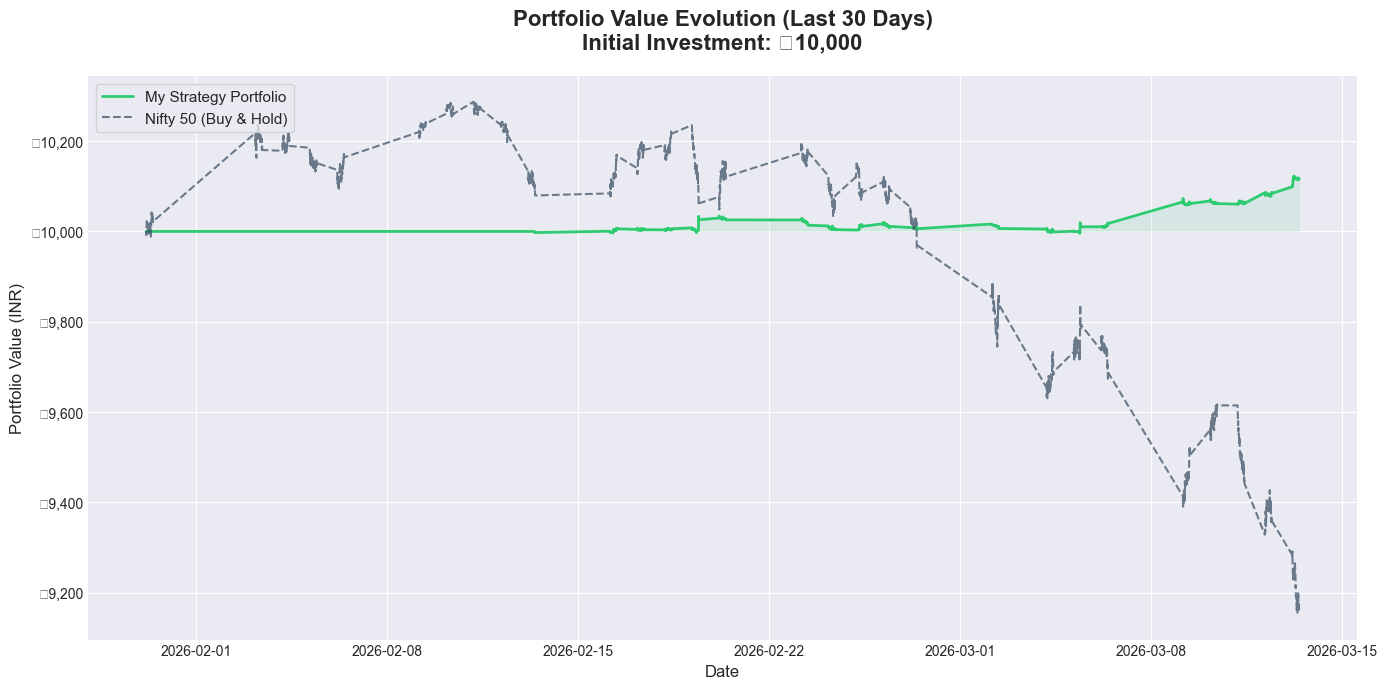

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Data for Plotting
initial_investment = 10000

# Calculate Cumulative Growth for Portfolio
# (1 + r).cumprod() gives us the growth factor
portfolio_df = portfolio_df.reindex(data.index).fillna(0)
# This will force the green line to start at the same X-coordinate as the blue line
portfolio_df['cum_growth'] = (1 + portfolio_df['portfolio_ret']).cumprod()
portfolio_df['portfolio_value'] = portfolio_df['cum_growth'] * initial_investment

# Calculate Cumulative Growth for Nifty 50 (Baseline)
# We calculate returns from the 'Close' price of your 'data' variable
data['nifty_ret'] = data['Close'].pct_change().fillna(0)
data['nifty_cum_growth'] = (1 + data['nifty_ret']).cumprod()
data['nifty_value'] = data['nifty_cum_growth'] * initial_investment

# 2. Plotting
plt.style.use('seaborn-v0_8-darkgrid') # Gives it a modern, clean look
fig, ax = plt.subplots(figsize=(14, 7))

# Plotting the lines
ax.plot(portfolio_df.index, portfolio_df['portfolio_value'], 
        label='My Strategy Portfolio', color='#2ecc71', linewidth=2)
ax.plot(data.index, data['nifty_value'], 
        label='Nifty 50 (Buy & Hold)', color='#34495e', linestyle='--', alpha=0.7)

# 3. Formatting the Chart
ax.set_title(f'Portfolio Value Evolution (Last 30 Days)\nInitial Investment: ₹{initial_investment:,}', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value (INR)', fontsize=12)

# Fill the area under the strategy curve for better visuals
ax.fill_between(portfolio_df.index, portfolio_df['portfolio_value'], initial_investment, 
                where=(portfolio_df['portfolio_value'] >= initial_investment), 
                color='#2ecc71', alpha=0.1)

# Formatting the Y-axis to show commas for currency
from matplotlib.ticker import StrMethodFormatter
ax.yaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))

plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()

plt.show()

In [40]:
## Risk adjusted metrics

beta, alpha, portfolio_ret, benchmark_ret, ann_port_ret, ann_bench_ret = jensens_alpha(portfolio_df['portfolio_ret'], data['nifty_ret'], 30/365)

print(f"--- Risk-Adjusted Metrics ---")
print(f"Portfolio Beta:             {beta:.2f}")
print(f"Total Strategy Ret:         {portfolio_ret:.2%}")
print(f"Total Nifty Ret:            {benchmark_ret:.2%}")
print(f"Jensen's Alpha:             {alpha:.2%}")
print(f"Annualized Nifty Ret:       {ann_bench_ret:.2%}")
print(f"Annualized Portfolio Ret:   {ann_port_ret:.2%}")



--- Risk-Adjusted Metrics ---
Portfolio Beta:             -0.06
Total Strategy Ret:         1.17%
Total Nifty Ret:            -8.27%
Jensen's Alpha:             3.99%
Annualized Nifty Ret:       -65.00%
Annualized Portfolio Ret:   15.15%
